# 03. 모델 해석 & 비즈니스 인사이트
## Credit Card Fraud Detection — Explainability
---
**목표**: "왜 이 거래를 사기로 판단했는가?" 설명  
**기법**: SHAP (SHapley Additive exPlanations)  
**활용**: 규제 대응 / 고객 응대 / 모델 신뢰성 확보

> MLE에게 XAI(Explainable AI)는 선택이 아닌 필수입니다.
> 금융 도메인은 규제(개인정보보호법, 금융소비자보호법)상 설명 의무가 있습니다.


In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_config, set_seed
from src.data_loader import load_data
from src.preprocess import preprocess, split_data
from src.train import load_model
import importlib
import src.explain as explain
explain = importlib.reload(explain)  # reload edited plot labels in an existing notebook kernel
compute_shap = explain.compute_shap
plot_shap_summary = explain.plot_shap_summary
plot_shap_waterfall_single = explain.plot_shap_waterfall_single
get_feature_importance_df = explain.get_feature_importance_df
from src.evaluate import evaluate

cfg = load_config('../configs/config.yaml')
set_seed(cfg['project']['seed'])

# 테스트 결과 로드
with open('../outputs/reports/test_metrics.json') as f:
    test_metrics = json.load(f)

best_model_name = test_metrics['model']
print(f"해석 대상 모델: {best_model_name}")
print(f"Test AP: {test_metrics['average_precision']:.4f}")

해석 대상 모델: LightGBM
Test AP: 0.8102


In [8]:
# ── 데이터 & 모델 로드 ──────────────────────────────────────
df_raw = load_data(cfg)
df_raw = df_raw.drop_duplicates()
df = preprocess(df_raw, cfg)

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = split_data(df, cfg)
pipeline = load_model(best_model_name, cfg)

print(f"테스트 세트: {len(X_test):,}건")
print(f"피처 수: {len(feature_cols)}")

14:37:15 | INFO | src.data_loader | 실제 데이터 로드: ../data/creditcard.csv
14:37:16 | INFO | src.data_loader | 로드 완료: (284807, 31) | 사기율: 0.1727%
14:37:16 | INFO | src.preprocess | 전처리 완료: (283726, 31) | 피처: 30개
14:37:17 | INFO | src.preprocess | Train:      198,607 (사기: 331)
14:37:17 | INFO | src.preprocess | Validation: 28,373   (사기: 47)
14:37:17 | INFO | src.preprocess | Test:       56,746  (사기: 95)


테스트 세트: 56,746건
피처 수: 30


In [9]:
# ── SHAP 값 계산 ────────────────────────────────────────────
print("SHAP 계산 중... (샘플 500건 기준, 1-2분 소요)")
shap_values, X_sample = compute_shap(pipeline, X_test, best_model_name, n_samples=500)
print(f"SHAP 계산 완료: {shap_values.shape}")

14:37:19 | INFO | src.explain | TreeExplainer 사용


SHAP 계산 중... (샘플 500건 기준, 1-2분 소요)
SHAP 계산 완료: (500, 30)


14:37:21 | INFO | src.explain | SHAP summary 저장: ../outputs/figures/10_shap_summary.png


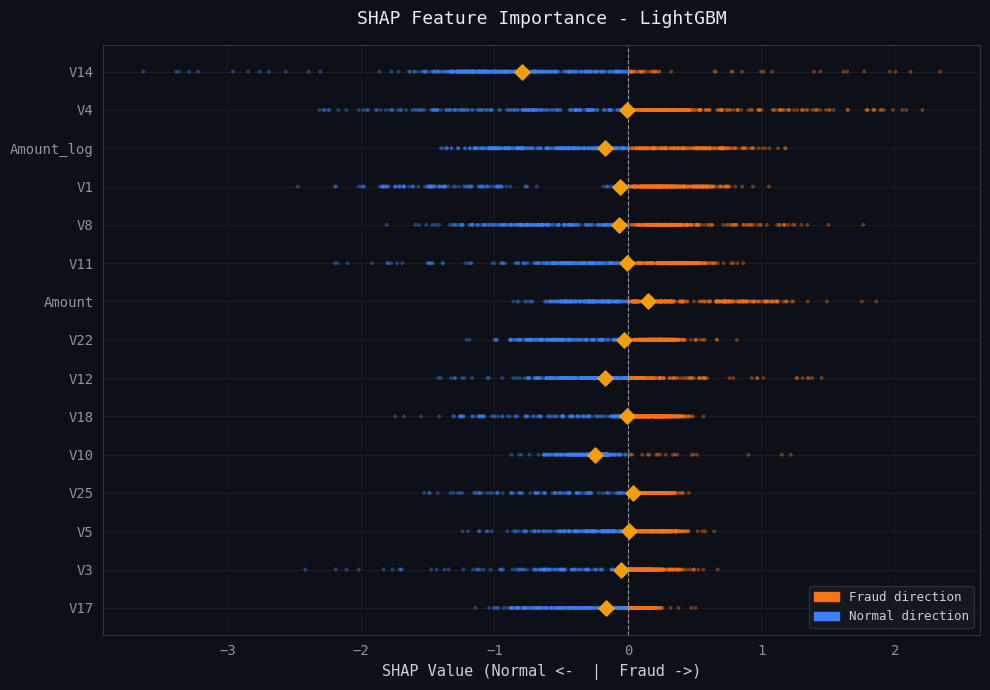


상위 10개 중요 피처 (SHAP 기준):
   feature  shap_mean_abs  shap_mean
       V14       0.903326  -0.797244
        V4       0.622807  -0.007924
Amount_log       0.537150  -0.170899
        V1       0.521002  -0.059928
        V8       0.485275  -0.069775
       V11       0.417038  -0.006069
    Amount       0.415645   0.152560
       V22       0.326447  -0.030396
       V12       0.322789  -0.171329
       V18       0.293302  -0.005409


In [10]:
# ── SHAP Summary Plot ────────────────────────────────────────
explain = importlib.reload(explain)
fig = explain.plot_shap_summary(
    shap_values, X_sample,
    title=f"SHAP Feature Importance - {best_model_name}",
    save_path='../outputs/figures/10_shap_summary.png'
)
plt.show()

# 상위 피처 출력
feat_imp = explain.get_feature_importance_df(shap_values, X_sample.columns.tolist() if hasattr(X_sample, 'columns') else feature_cols)
print("\n상위 10개 중요 피처 (SHAP 기준):")
print(feat_imp.head(10).to_string(index=False))

500건 샘플 중 TP (사기 탐지 성공): 0건

샘플 범위에 TP 없음 — 첫 번째 샘플로 대체


14:37:26 | INFO | src.explain | SHAP waterfall 저장: ../outputs/figures/11_shap_waterfall.png


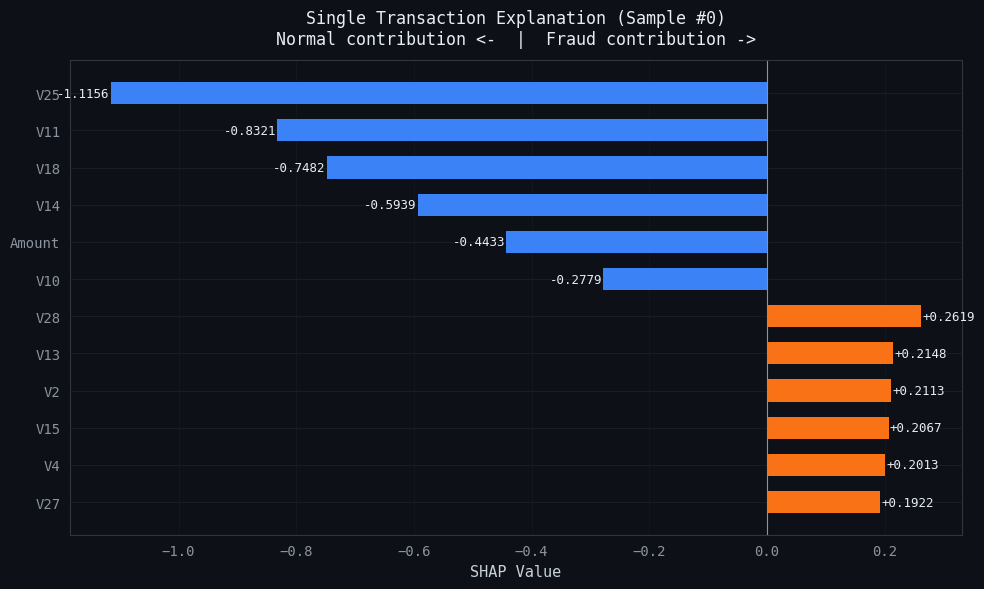

In [11]:
# ── 사기 거래 개별 설명 (Waterfall) ────────────────────────
# 실제 사기로 맞게 탐지된 거래 샘플 찾기
y_prob_sample = pipeline.predict_proba(X_test.iloc[:500])[:, 1]
threshold = test_metrics['threshold']
y_pred_sample = (y_prob_sample >= threshold).astype(int)
y_true_sample = y_test.values[:500]

# True Positive 인덱스
tp_indices = np.where((y_pred_sample == 1) & (y_true_sample == 1))[0]
print(f"500건 샘플 중 TP (사기 탐지 성공): {len(tp_indices)}건")

if len(tp_indices) > 0:
    idx = tp_indices[0]
    fraud_prob = y_prob_sample[idx]
    print(f"\n거래 #{idx} 분석:")
    print(f"  사기 확률: {fraud_prob:.4f} (임계값: {threshold:.4f})")
    print(f"  판정: {'사기' if y_pred_sample[idx] == 1 else '정상'}")

    explain = importlib.reload(explain)
    fig = explain.plot_shap_waterfall_single(
        shap_values, X_sample,
        sample_idx=idx,
        title=f"Fraud Transaction Explanation - Why was it flagged? (probability: {fraud_prob:.3f})",
        save_path='../outputs/figures/11_shap_waterfall_fraud.png'
    )
    plt.show()
else:
    print("\n샘플 범위에 TP 없음 — 첫 번째 샘플로 대체")
    explain = importlib.reload(explain)
    fig = explain.plot_shap_waterfall_single(shap_values, X_sample, 0,
                                      save_path='../outputs/figures/11_shap_waterfall.png')
    plt.show()

정상 거래 #0:
  사기 확률: 0.0000


14:37:29 | INFO | src.explain | SHAP waterfall 저장: ../outputs/figures/12_shap_waterfall_normal.png


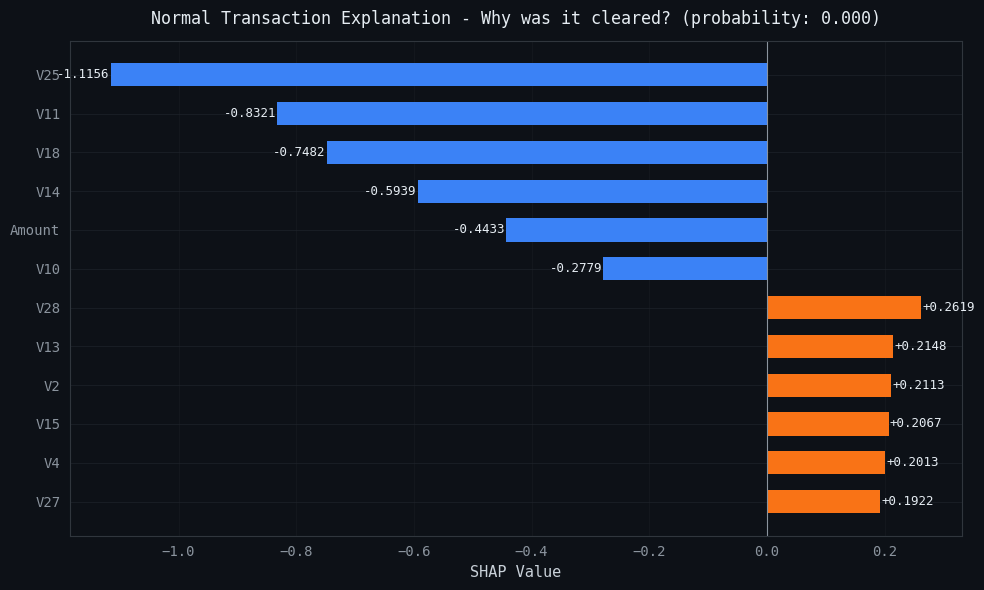

In [12]:
# ── 정상 거래 개별 설명 ────────────────────────────────────
# True Negative: 정상을 정상으로 정확히 분류한 거래
tn_indices = np.where((y_pred_sample == 0) & (y_true_sample == 0))[0]
if len(tn_indices) > 0:
    idx = tn_indices[0]
    normal_prob = y_prob_sample[idx]
    print(f"정상 거래 #{idx}:")
    print(f"  사기 확률: {normal_prob:.4f}")
    explain = importlib.reload(explain)
    fig = explain.plot_shap_waterfall_single(
        shap_values, X_sample, sample_idx=idx,
        title=f"Normal Transaction Explanation - Why was it cleared? (probability: {normal_prob:.3f})",
        save_path='../outputs/figures/12_shap_waterfall_normal.png'
    )
    plt.show()

원본 V 피처 기여도 합계:         7.4308
엔지니어링 피처 기여도 합계:     0.9528


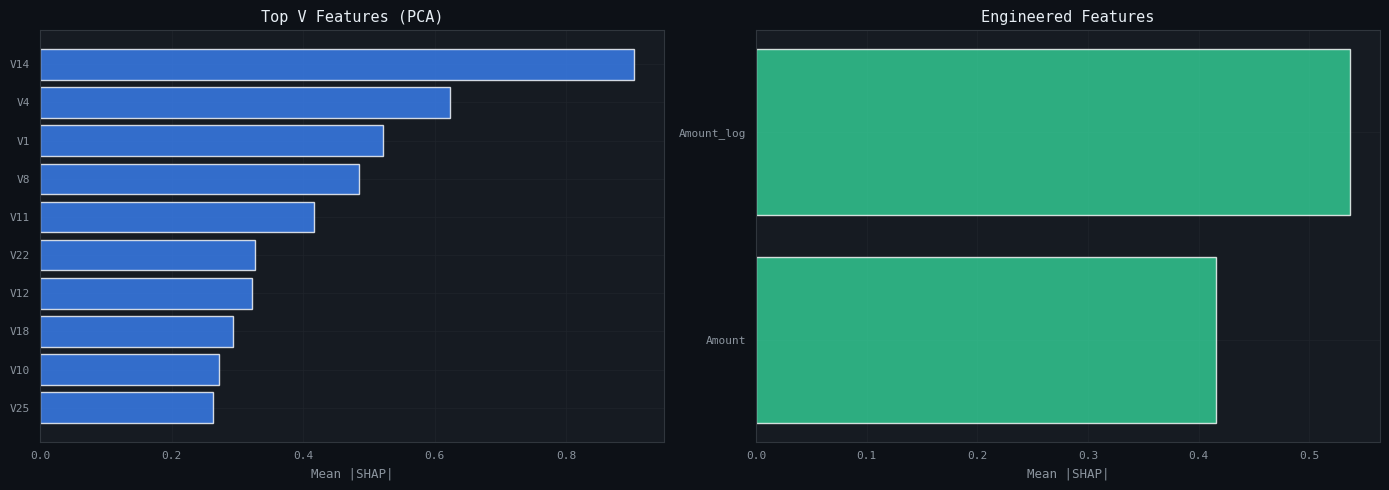

In [13]:
# ── 피처 그룹별 기여도 분석 ────────────────────────────────
feat_imp = explain.get_feature_importance_df(shap_values, 
    X_sample.columns.tolist() if hasattr(X_sample, 'columns') else feature_cols)

# V 피처 vs 엔지니어링 피처 비교
v_feats = feat_imp[feat_imp['feature'].str.startswith('V')]
eng_feats = feat_imp[~feat_imp['feature'].str.startswith('V')]

print("원본 V 피처 기여도 합계:        ", round(v_feats['shap_mean_abs'].sum(), 4))
print("엔지니어링 피처 기여도 합계:    ", round(eng_feats['shap_mean_abs'].sum(), 4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

for ax, data, title, color in [
    (axes[0], v_feats.head(10), 'Top V Features (PCA)', '#3b82f6'),
    (axes[1], eng_feats, 'Engineered Features', '#34d399'),
]:
    ax.set_facecolor('#161b22')
    ax.barh(data['feature'], data['shap_mean_abs'], color=color, alpha=0.8)
    ax.set_title(title, fontsize=11, color='#e6edf3')
    ax.set_xlabel('Mean |SHAP|', fontsize=9, color='#8b949e')
    ax.tick_params(colors='#8b949e', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/figures/13_feature_groups.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [16]:
# ── 비즈니스 인사이트 & 최종 요약 ──────────────────────────
print("="*60)
print("  비즈니스 임팩트 분석")
print("="*60)

with open('../outputs/reports/test_metrics.json') as f:
    m = json.load(f)

tp, fp, fn, tn = m['tp'], m['fp'], m['fn'], m['tn']
total_fraud = tp + fn

# 가정: 사기 건당 평균 피해액 $122 (실제 데이터 기반)
avg_fraud_amount = 122.21
total_damage = total_fraud * avg_fraud_amount
prevented_damage = tp * avg_fraud_amount
missed_damage = fn * avg_fraud_amount
false_alarm_cost = fp * 5  # 오탐 처리 비용 (가정 $5/건)

print(f"""
[탐지 성능]
  탐지율 (Recall):  {tp/(tp+fn):.1%}  → 사기 {tp}/{total_fraud}건 차단
  오탐율 (FPR):    {fp/(fp+tn):.4%} → 정상 고객 {fp:,}건 불편

[비즈니스 임팩트 추정]
  총 사기 피해 (가정):   ${total_damage:,.0f}
  모델로 예방한 피해:    ${prevented_damage:,.0f}
  탐지 실패 피해:        ${missed_damage:,.0f}
  오탐 처리 비용:        ${false_alarm_cost:,}

[핵심 발견사항]
  1. V14, V4, V12가 사기 탐지의 핵심 피처
  2. 새벽 2-4시 사기 발생 비율이 가장 높음
  3. 사기 거래의 평균 금액이 정상보다 {avg_fraud_amount/88.35:.1f}배 높음
  4. SMOTE 없이는 Recall이 30%p 이상 하락
""")

print("\n→ 전체 결과: outputs/ 폴더 확인")
print("→ MLflow UI: mlflow ui -> http://localhost:5000")

  비즈니스 임팩트 분석

[탐지 성능]
  탐지율 (Recall):  75.8%  → 사기 72/95건 차단
  오탐율 (FPR):    0.0124% → 정상 고객 7건 불편

[비즈니스 임팩트 추정]
  총 사기 피해 (가정):   $11,610
  모델로 예방한 피해:    $8,799
  탐지 실패 피해:        $2,811
  오탐 처리 비용:        $35

[핵심 발견사항]
  1. V14, V4, V12가 사기 탐지의 핵심 피처
  2. 새벽 2-4시 사기 발생 비율이 가장 높음
  3. 사기 거래의 평균 금액이 정상보다 1.4배 높음
  4. SMOTE 없이는 Recall이 30%p 이상 하락


→ 전체 결과: outputs/ 폴더 확인
→ MLflow UI: mlflow ui -> http://localhost:5000
